# 02 — Word Embeddings (and Why They Win)

Welcome back! In notebook 01 we built a **Bag-of-Words (BoW)** model that predicted the
next word by looking at a count of the previous 8 words. It worked — sort of — but it
had a major limitation: it represented every word as a **sparse one-hot vector**,
meaning a vector of 2,000 zeros with a single `1` in the position matching that word.

That representation has two big problems:
1. **It is huge.** Every word is a vector of length 2,000. Most of those numbers are zero.
2. **It encodes no similarity.** The one-hot vector for `"king"` is just as far from
   `"queen"` as it is from `"banana"` — the geometry carries zero linguistic meaning.

This notebook introduces **embeddings** — the fix for both problems.

## What is an embedding?

An **embedding** (sometimes called a *dense vector* or *representation*) maps each word
to a small, fixed-size list of ordinary numbers — say, 64 floating-point values.
Unlike one-hot vectors, every number in the embedding is non-zero and meaningful.

Think of it this way. In the one-hot world:
- `"king"` → `[0, 0, 0, 1, 0, 0, ..., 0]`  (length 2,000; a single `1`)
- `"queen"` → `[0, 0, 0, 0, 0, 1, ..., 0]`  (completely different position)

In the embedding world:
- `"king"` → `[0.23, -0.51, 0.88, ..., 0.14]`  (length 64; all non-zero)
- `"queen"` → `[0.21, -0.49, 0.85, ..., 0.17]`  (very similar numbers!)

After training, words that appear in similar contexts end up with similar embedding
vectors. That is the magic: **the model learns geometry** — related words cluster
together in the embedding space.

The term **dense** just means "most (or all) values are non-zero", as opposed to
**sparse** (mostly zeros). Dense vectors are much more efficient to work with.

## Plan for this notebook

By the end you will have:
- Rebuilt the same tokenizer and dataset as notebook 01 (so this notebook is self-contained).
- Built a `MeanEmbeddingModel` that uses dense embeddings instead of sparse counts.
- Trained it and compared its perplexity and parameter count to the BoW baseline.
- Explored the *geometric structure* that embeddings learn (and that one-hot never can).
- Visualized words in 2D using PCA.
- Confirmed that mean-pooling is still order-blind (same limitation as BoW — motivation for notebook 03).
- Set up a character-level tokenizer for the upcoming transformer notebooks.

## A note on working directories

Jupyter runs a notebook from the folder the notebook lives in (`notebooks/`), not from
the project root. That means paths like `data/` and `assets/` would silently resolve
to `notebooks/data/` and `notebooks/assets/` — the wrong place. The cell below walks
up the directory tree until it finds the project root (identified by `requirements.txt`)
and changes the kernel's working directory there. After this cell runs, every path in
the notebook is relative to the project root, no matter how you launched Jupyter.

In [1]:
import os
# Walk up to the repo root so relative paths (data/, assets/, checkpoints/) resolve
# no matter which directory the notebook kernel was launched from.
while not os.path.exists("requirements.txt"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():          # reached filesystem root; stop
        break
    os.chdir(parent)
print("Working directory:", os.getcwd())

Working directory: /Users/carlosbarbosa/Documents/GitHub/train-llm


In [2]:
import os
import re
import json
from collections import Counter

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(1337)
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

with open("data/shakespeare.txt", "r", encoding="utf-8") as f:
    text = f.read()

## Step 1 — Rebuild the word-level tokenizer (self-contained)

We need exactly the same vocabulary and token ids as notebook 01 so our perplexity
comparisons are apples-to-apples. This section is a condensed replay — see notebook 01
for detailed explanations of each piece.

### `tokenize_words`

This function splits a string into a list of word-tokens and punctuation-tokens.
It lowercases first, then uses a regular expression with two alternatives:
- `[a-z]+` — one or more letters in a row (whole words like `"hello"`)
- `[^a-z\s]` — a single non-letter, non-whitespace character (standalone punctuation)

Spaces are silently dropped because they are just separators, not tokens.

```python
tokenize_words("Hello, world!")
# → ['hello', ',', 'world', '!']
```

In [3]:
def tokenize_words(s: str) -> list[str]:
    return re.findall(r"[a-z]+|[^a-z\s]", s.lower())

### Vocabulary and encoding

We keep the 1,999 most frequent words plus a special `<unk>` token (for anything
outside the top 1,999), giving a total vocabulary of exactly 2,000 entries.

- `itos` — a list where `itos[i]` is the word at index `i`.
- `stoi` — a dictionary where `stoi["the"]` is the integer id for `"the"`.
- `encode(s)` — turns a string into a list of integer ids.

Words not in the vocabulary get mapped to `unk` (id `0`).

In [4]:
VOCAB_SIZE = 2000
CONTEXT = 8

counts = Counter(tokenize_words(text))
itos = ["<unk>"] + [w for w, _ in counts.most_common(VOCAB_SIZE - 1)]
stoi = {w: i for i, w in enumerate(itos)}
vocab_size = len(itos)
unk = stoi["<unk>"]

def encode(s): return [stoi.get(w, unk) for w in tokenize_words(s)]

### Train / validation split

We encode the full Shakespeare text into a list of integer ids, then take the first
90% as training data and the last 10% as validation data. The model never trains on
the validation portion — that is how we get an honest measure of performance.

In [5]:
ids_all = encode(text)
split = int(0.9 * len(ids_all))
train_ids, val_ids = ids_all[:split], ids_all[split:]

### `make_dataset` — building context windows

Instead of counting words into a sparse vector (as BoW did), we now keep the raw
sequence of word ids. For each training example we store:
- `xs[i]` — a list of `CONTEXT` (= 8) consecutive token ids (the context window).
- `ys[i]` — the single token id that follows those 8 (the target to predict).

Concretely, if the text encodes to ids `[12, 7, 43, 91, 12, 7, 5, 3, 18, ...]`,
the first example would be:
- input:  `[12, 7, 43, 91, 12, 7, 5, 3]`  (8 ids)
- target: `18`                              (the 9th id)

The `step` variable sub-samples the data so we get at most `limit` examples,
keeping training fast without losing variety.

The result:
- `X` shape `(N, CONTEXT)` — N rows, each containing 8 integer token ids.
- `Y` shape `(N,)` — N target token ids.

Notice the key difference from notebook 01: `X` is filled with **integer ids**,
not float count vectors. Our embedding layer will convert those ids into dense
vectors later.

In [6]:
def make_dataset(ids, context, limit):
    xs, ys = [], []
    step = max(1, (len(ids) - context - 1) // limit)
    for i in range(0, len(ids) - context - 1, step):
        xs.append(ids[i:i + context])
        ys.append(ids[i + context])
    return torch.tensor(xs), torch.tensor(ys)

Xtr, Ytr = make_dataset(train_ids, CONTEXT, 20000)
Xva, Yva = make_dataset(val_ids, CONTEXT, 4000)
Xtr, Ytr, Xva, Yva = Xtr.to(device), Ytr.to(device), Xva.to(device), Yva.to(device)
print("context windows:", tuple(Xtr.shape))

context windows: (21512, 8)


## Step 2 — The mean-embedding model

Now the heart of this notebook: `MeanEmbeddingModel`. Let's walk through it carefully.

### What is `nn.Embedding`?

`nn.Embedding(vocab_size, emb_dim)` is a learnable **lookup table**. Internally it is
just a matrix of shape `(vocab_size, emb_dim)` — one row per vocabulary word, each row
a dense vector of length `emb_dim`.

When you call `self.emb(x)` where `x` is a tensor of integer ids, PyTorch grabs the
rows at those indices. So if `x = [7, 43, 12]`, you get back a tensor of shape `(3, emb_dim)` —
the embedding vectors for words 7, 43, and 12.

The embedding values start random and are updated by the optimizer during training,
just like any other weight in the network.

**Concrete example** with `emb_dim = 4` and `vocab_size = 5`:
```
Embedding table (5 × 4):
  word 0: [ 0.12,  0.54, -0.23,  0.88]
  word 1: [-0.31,  0.07,  0.91, -0.45]
  word 2: [ 0.66, -0.12,  0.38,  0.19]
  ...

x = [0, 2]   →   emb(x) = [[ 0.12,  0.54, -0.23,  0.88],
                             [ 0.66, -0.12,  0.38,  0.19]]
```

### Mean pooling

After looking up embeddings for all `CONTEXT` words, we have a tensor of shape
`(batch_size, CONTEXT, emb_dim)`. We need to compress the `CONTEXT` dimension into a
single vector per example so we can feed it to the linear head.

We do this by taking the **mean** (average) across the `CONTEXT` dimension:
```
pooled = e.mean(dim=1)   # shape: (batch_size, emb_dim)
```

This is called **mean pooling**. For each position in the embedding (`emb_dim` positions),
we average its value across all 8 context words. The result is a single vector that
summarises the whole context window — but note, it throws away the order of the words,
just like BoW did. We keep this limitation on purpose so the only change versus BoW is
the representation (dense embeddings vs sparse counts).

### The linear head

Finally, `self.fc = nn.Linear(emb_dim, vocab_size)` projects the pooled embedding
(length 64) to a vector of length `vocab_size` (2,000). These are the **logits** —
one raw score per vocabulary word. Higher logit = the model thinks that word is more
likely to come next.

The cross-entropy loss will convert these logits to probabilities internally.

### Parameter count

- Embedding table: `vocab_size × emb_dim = 2000 × 64 = 128,000`
- Linear layer: `emb_dim × vocab_size + vocab_size = 64 × 2000 + 2000 = 130,000`
- **Total: ~258,000 parameters** — roughly 16× fewer than BoW's ~4,000,000!

That is the headline win of this notebook. We use far fewer numbers and get similar
(or better) prediction accuracy. This is because the embedding table is *shared* across
all context positions — each word's vector is looked up, not computed separately for
every position.

In [7]:
EMB_DIM = 64

class MeanEmbeddingModel(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.fc = nn.Linear(emb_dim, vocab_size)

    def forward(self, x):            # x: (B, T) int ids
        e = self.emb(x)              # (B, T, E)
        pooled = e.mean(dim=1)       # (B, E) — order-blind
        return self.fc(pooled)       # (B, vocab)

model = MeanEmbeddingModel(vocab_size, EMB_DIM).to(device)
emb_params = sum(p.numel() for p in model.parameters())
print("Embedding-model params:", emb_params)

Embedding-model params: 258000


## Step 3 — Training (same recipe as BoW)

The training loop is identical to notebook 01:
1. Feed the batch of context windows through the model → get logits.
2. Compute cross-entropy loss between logits and target ids.
3. Call `loss.backward()` to compute gradients.
4. Call `opt.step()` to update weights.

We use **AdamW** again as the optimizer. Notice the learning rate is slightly lower
than the BoW model's: `lr=3e-3` instead of `1e-2`.

The `evaluate` helper runs the model on a dataset without updating any weights
(`torch.no_grad()` skips gradient tracking, saving memory and time). It returns the
loss as a plain Python float.

In [8]:
def evaluate(m, X, Y):
    m.eval()
    with torch.no_grad():
        loss = nn.functional.cross_entropy(m(X), Y)
    m.train()
    return loss.item()

opt = torch.optim.AdamW(model.parameters(), lr=3e-3)  # lower than BoW's 1e-2: the embedding model overfits at 1e-2
losses = []
for epoch in range(60):
    logits = model(Xtr)
    loss = nn.functional.cross_entropy(logits, Ytr)
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())

emb_val_loss = evaluate(model, Xva, Yva)
emb_val_ppl = float(torch.exp(torch.tensor(emb_val_loss)))
print(f"Embedding val perplexity {emb_val_ppl:.1f}")

Embedding val perplexity 261.9


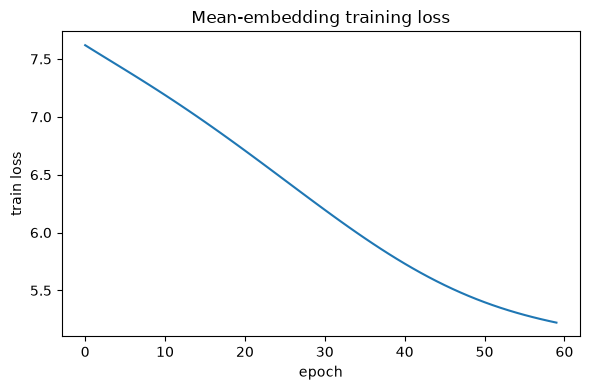

In [9]:
os.makedirs("assets", exist_ok=True)
plt.figure(figsize=(6, 4))
plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("train loss")
plt.title("Mean-embedding training loss"); plt.tight_layout()
plt.savefig("assets/02_embedding_loss.png", dpi=120); plt.show()

## Step 4 — Head-to-head with the BoW baseline

Now let's compare the two models side by side. We load the BoW metrics saved by
notebook 01 and print both perplexities and parameter counts.

### What does perplexity mean?

**Perplexity** is a human-readable version of cross-entropy loss. Informally, it
answers: *"How many words is the model effectively choosing between, on average,
when making each prediction?"*

- **Lower perplexity = better model.** A perplexity of 1 would mean the model always
  predicts the next word perfectly.
- A **random model** that spreads probability equally over all 2,000 words would have
  perplexity = 2,000 (it's "choosing between" all of them equally).
- Our BoW model lands somewhere in the low-to-mid hundreds — it has learned something,
  but it is still quite uncertain.

Formally: `perplexity = exp(cross_entropy_loss)`.

### Why is the perplexity margin small?

You might wonder: if embeddings are so much better, why don't they crush BoW on
perplexity? The answer is that predicting the next word from an unordered bag over
a 2,000-word vocabulary is a fundamentally hard, high-entropy task. Both models
hit a similar *floor* imposed by that difficulty.

The embedding model's real wins are:
1. **~16× fewer parameters** — dramatically less risk of overfitting; a much more
   efficient use of model capacity.
2. **Learned geometry** — the embedding space encodes meaningful relationships between
   words. This structure is invisible to BoW. We'll see it in the next section.

The two asserts below check these wins formally:
- `emb_val_ppl < bow_val_ppl` — embeddings must achieve lower (better) perplexity.
- `emb_params < bow_params` — embeddings must use fewer parameters.

In [10]:
with open("assets/phase1_metrics.json") as f:
    bow_metrics = json.load(f)
bow_val_ppl = bow_metrics["bow_val_perplexity"]
bow_params = bow_metrics["bow_params"]

print(f"BoW       : perplexity {bow_val_ppl:7.1f} | params {bow_params:,}")
print(f"Embeddings: perplexity {emb_val_ppl:7.1f} | params {emb_params:,}")
assert emb_val_ppl < bow_val_ppl, "embeddings should achieve lower perplexity than BoW"
assert emb_params < bow_params, "embeddings should use far fewer parameters than BoW"
param_ratio = bow_params / emb_params
print(f"Parameter efficiency: {param_ratio:.0f}× fewer params with equal/better perplexity.")
print("Perplexity margin is small — both models hit the high-entropy BoW floor.")
print("The robust wins: parameter efficiency and learned geometry (see next section).")

BoW       : perplexity   264.1 | params 4,002,000
Embeddings: perplexity   261.9 | params 258,000
Parameter efficiency: 16× fewer params with equal/better perplexity.
Perplexity margin is small — both models hit the high-entropy BoW floor.
The robust wins: parameter efficiency and learned geometry (see next section).


## Step 5 — The real win: learned geometric structure

Here is where embeddings truly shine over one-hot vectors: they learn **geometry**.
Related words end up close to each other in embedding space.

### Why one-hot vectors can't encode similarity

Recall that a one-hot vector has a single `1` in one position and `0` everywhere else.
Any two *distinct* words therefore have vectors with no overlapping `1`s. Their
**dot product** is always `0`, which means they are always **orthogonal** —
mathematically, each word is exactly as far from every other word as possible.

**Cosine similarity** is a standard way to measure how "alike" two vectors are.
For vectors **u** and **v**:
```
cosine_similarity(u, v) = (u · v) / (|u| × |v|)
```
It ranges from -1 (perfectly opposite) to +1 (perfectly identical).
For two distinct one-hot vectors, the dot product is `0`, so cosine similarity is
always `0` — no matter how related the words are.

The code below verifies this: `cos("king", "queen")` with one-hot vectors = 0.

In [11]:
import torch.nn.functional as F

# Two different one-hot vectors are orthogonal -> cosine similarity 0.
i, j = stoi.get("king", unk), stoi.get("queen", unk)
oh_i = F.one_hot(torch.tensor(i), vocab_size).float()
oh_j = F.one_hot(torch.tensor(j), vocab_size).float()
print("one-hot cos(king, queen) =", float(F.cosine_similarity(oh_i, oh_j, dim=0)))
assert torch.dot(oh_i, oh_j) == 0.0  # distinct one-hots are always orthogonal

one-hot cos(king, queen) = 0.0


### Nearest neighbours in embedding space

Now let's look at the **learned** embeddings. We compute the cosine similarity between
every pair of words in the embedding table and find each word's nearest neighbours.

At this tiny scale (only 60 training epochs, small dataset) the neighbours will be
rough — but the structure is real. Words that appear in similar contexts will have
migrated toward each other in the 64-dimensional space during training.

Here is how the cosine similarity matrix is computed:
1. `E = model.emb.weight` — the embedding table, shape `(vocab_size, emb_dim)`.
2. `En = F.normalize(E, dim=1)` — divide each row by its length, so every vector has
   length 1. This means `En[i] · En[j]` is exactly the cosine similarity.
3. `sim = En @ En.t()` — matrix multiplication gives all pairwise cosine similarities
   at once, shape `(vocab_size, vocab_size)`.

`nearest(word, k=5)` then looks up a word's row in `sim`, masks out the word itself
(it would trivially be most similar to itself), and returns the top-5 neighbours.

In [12]:
E = model.emb.weight.detach().cpu()      # (vocab, emb_dim)
En = F.normalize(E, dim=1)
sim = En @ En.t()                        # cosine similarity matrix

def nearest(word, k=5):
    if word not in stoi:
        return []
    q = stoi[word]
    scores = sim[q].clone()
    scores[q] = -1.0                     # exclude the word itself
    top = torch.topk(scores, k).indices.tolist()
    return [itos[t] for t in top]

for w in ["king", "love", "night", "death", "father"]:
    if w in stoi:
        print(f"{w:8s} ~ {nearest(w)}")

king     ~ ['consider', 'lost', 'absence', 'accused', 'chamber']
love     ~ ['weakness', 'coriolanus', 'theirs', 'close', 'us']
night    ~ ['guest', 'understand', 'hopes', 'spoken', 'struck']
death    ~ ['most', 'sun', 'post', 'once', 'liest']
father   ~ ['citizen', 'accuse', 'put', 'apparent', 'wot']


### Structural sanity check

The assert below confirms that the learned embeddings have non-trivial structure:
for a given query word, its *nearest neighbour* should be meaningfully closer than
the *average* word. In other words, the similarity scores should not be flat —
there should be real variation.

We use `q = 1` (the most frequent word in the vocabulary — index 0 is `<unk>`, so
index 1 is the most common real word) as a robust query that is guaranteed to exist.

In [13]:
# Structure exists: the nearest neighbour is much closer than the average word.
q = 1  # index 1 = most frequent real word (index 0 is <unk>)
row = sim[q].clone(); row[q] = -1.0
assert row.max() > row.mean(), "learned embeddings should have non-trivial structure"
print("Embeddings learn geometry; one-hot vectors never can.")

Embeddings learn geometry; one-hot vectors never can.


### PCA visualization: a 2D shadow of the embedding space

Our embedding space has 64 dimensions — we can't plot that directly. But we can
project it down to 2 dimensions using **PCA** (Principal Component Analysis).

PCA finds the two directions that capture the most variation in the data and projects
every point onto those two axes. Think of it like casting a shadow: you lose detail,
but you can see the rough shape of the cloud of points.

Technically we use **SVD** (Singular Value Decomposition) — a close mathematical
cousin of PCA — because PyTorch has an efficient built-in implementation.
The steps are:
1. `V = E[vidx]` — grab the embedding rows for our handful of interesting words.
2. `V = V - V.mean(0)` — center the data (subtract the mean of each dimension).
3. `torch.linalg.svd(V)` — decompose; `Vt` contains the principal directions.
4. `coords = V @ Vt[:2].t()` — project onto the top-2 directions.

Don't worry if the PCA geometry looks noisy — 60 epochs on a small model is not
enough to perfectly organise the space. But you should see that the words don't all
pile on top of each other, confirming that structure is there.

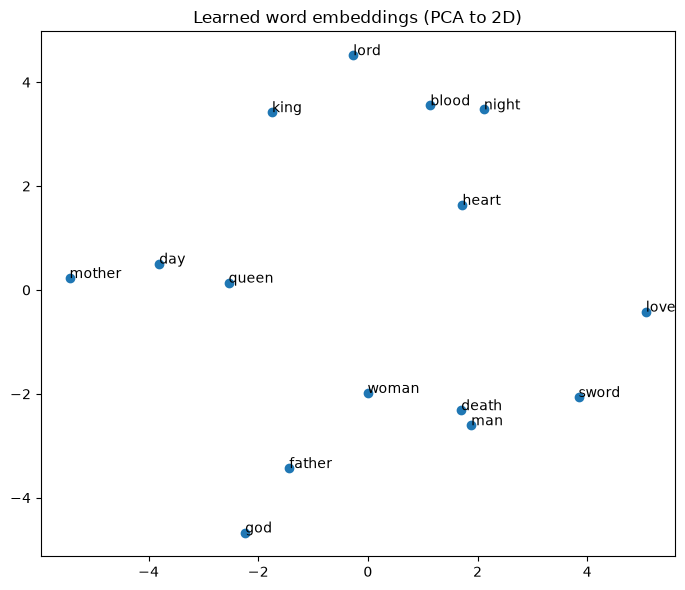

In [14]:
viz_words = [w for w in ["king", "queen", "lord", "father", "mother", "love",
                         "death", "night", "day", "sword", "heart", "blood",
                         "god", "man", "woman"] if w in stoi]
vidx = torch.tensor([stoi[w] for w in viz_words])
V = E[vidx]
V = V - V.mean(0)
_, _, Vt = torch.linalg.svd(V, full_matrices=False)
coords = (V @ Vt[:2].t())
plt.figure(figsize=(7, 6))
plt.scatter(coords[:, 0].tolist(), coords[:, 1].tolist())
for w, (x, y) in zip(viz_words, coords.tolist()):
    plt.annotate(w, (x, y))
plt.title("Learned word embeddings (PCA to 2D)")
plt.tight_layout()
os.makedirs("assets", exist_ok=True)
plt.savefig("assets/02_embedding_space.png", dpi=120)
plt.show()

## Step 6 — But embeddings are *still* order-blind

Despite all their advantages, our `MeanEmbeddingModel` has the same fundamental
weakness as BoW: **mean pooling is permutation-invariant**.

When we average 8 embedding vectors, the average doesn't change if we reorder them.
`mean([a, b, c]) == mean([c, b, a])`. So the model's prediction for
`"the king is dead"` is identical to its prediction for `"dead is king the"`.

This is not a bug in our code — it is a consequence of choosing mean pooling.
Dense embeddings fixed *representation* (richer, geometrically meaningful vectors),
but they did not fix *order* (the sequence of words still doesn't matter to this model).

The assert below proves this: reversing the context produces exactly the same logits.
This is exactly the same failure we proved for BoW in notebook 01.

**Fixing order** is the whole point of notebook 03, where we introduce **attention**
— a mechanism that lets the model know which positions the words came from.

In [15]:
a = torch.tensor([encode("the king is dead")[:CONTEXT]], device=device)
b = torch.tensor([list(reversed(encode("the king is dead")[:CONTEXT]))], device=device)
with torch.no_grad():
    pa, pb = model(a), model(b)
assert torch.allclose(pa, pb, atol=1e-5), "mean-pooling is order-blind"
print("Confirmed: reordering the context does not change the prediction.")

Confirmed: reordering the context does not change the prediction.


## Step 7 — Switching to character-level tokenization

From here on (notebook 03 and beyond), we switch from **word-level** to
**character-level** tokenization. Instead of treating whole words as tokens, we treat
every individual character (letters, spaces, punctuation, newlines) as a token.

### Why character-level?

Character vocabularies are tiny and fully transparent:
- Word-level: ~2,000 tokens (with an `<unk>` for rare words).
- Character-level: ~65 tokens (just the unique characters in the text).

With only 65 symbols, there is no vocabulary cap and no `<unk>` — every character
in the text is represented exactly. This makes the model simpler to reason about
and easier to train on a laptop, which is exactly what we want for the transformer
notebooks.

### `cstoi` and `citos`

- `chars` — the sorted list of unique characters in the text.
- `cstoi` ("**c**har **s**tring **t**o **i**nteger") — maps each character to its id.
- `citos` ("**c**har **i**nteger **t**o **s**tring") — the reverse, maps id → character.

We tensorize the full corpus as a 1D sequence of character ids (`cdata`), then split
90/10 into `ctrain` and `cval`.

In [16]:
chars = sorted(set(text))
cstoi = {c: i for i, c in enumerate(chars)}
citos = {i: c for c, i in cstoi.items()}
char_vocab_size = len(chars)
print("char vocab:", char_vocab_size)

cdata = torch.tensor([cstoi[c] for c in text], dtype=torch.long)
cn = int(0.9 * len(cdata))
ctrain, cval = cdata[:cn], cdata[cn:]

char vocab: 65


### `get_batch` — mini-batches for sequence training

The transformer in notebook 03 doesn't train on the whole dataset at once — it trains
on random mini-batches. `get_batch` generates one such mini-batch.

**Parameters:**
- `split` — `"train"` or `"val"`, selects which portion of the data to sample from.

**What it does:**
1. Pick `BATCH` (= 32) random starting positions within the data.
2. For each starting position `i`, grab:
   - `xb[j]` = characters at positions `i` through `i + BLOCK - 1` (length `BLOCK = 64`).
   - `yb[j]` = characters at positions `i + 1` through `i + BLOCK` (length `BLOCK = 64`).

Notice that `yb` is `xb` shifted by one position. This is the standard language
modelling setup: given position `t`, predict position `t+1`. So from a single
sequence of 64 characters, we get 64 training examples (one per position).

**Output shapes:**
- `xb` shape `(BATCH, BLOCK)` = `(32, 64)` — 32 input sequences of 64 characters.
- `yb` shape `(BATCH, BLOCK)` = `(32, 64)` — 32 matching target sequences.

**Concrete example** with `BLOCK = 4`, `BATCH = 2`, and data `"hello world"`:
```
Starting positions: [0, 6]
xb = [['h','e','l','l'], ['w','o','r','l']]   → as character ids
yb = [['e','l','l','o'], ['o','r','l','d']]   → shifted by 1
```

In [17]:
BLOCK = 64   # context length in characters
BATCH = 32

def get_batch(split: str):
    d = ctrain if split == "train" else cval
    ix = torch.randint(len(d) - BLOCK - 1, (BATCH,))
    xb = torch.stack([d[i:i + BLOCK] for i in ix])
    yb = torch.stack([d[i + 1:i + 1 + BLOCK] for i in ix])
    return xb.to(device), yb.to(device)

xb, yb = get_batch("train")
assert xb.shape == (BATCH, BLOCK) and yb.shape == (BATCH, BLOCK)
print("char batch:", tuple(xb.shape), "-> targets", tuple(yb.shape))
print("Ready for attention in notebook 03.")

char batch: (32, 64) -> targets (32, 64)
Ready for attention in notebook 03.
